# MediTrack: Predictive Modeling & Clinical Threshold Tuning
### Project CP-02: Readmission Risk Prediction and Clinical Decision Support
This notebook compares Logistic Regression, Random Forest, and Gradient Boosting under class weighting, evaluates decision thresholds, and defends the recall vs. precision trade-off.

In [1]:

import json
import pandas as pd
import matplotlib.pyplot as plt

with open('reports/model_evaluation_report.json') as f:
    report = json.load(f)

# Model Comparison Table
comp_rows = []
for name, res in report['models_comparison'].items():
    comp_rows.append({
        'Model': name,
        'ROC-AUC': res['roc_auc'],
        'PR-AUC': res['pr_auc'],
        'Brier Score': res['brier_score'],
        'Sensitivity @ 0.50': res['default_threshold_0_5']['sensitivity_recall'],
        'Precision @ 0.50': res['default_threshold_0_5']['precision_ppv'],
        'Tuned Clinical Threshold': res['clinical_operational_threshold']['threshold'],
        'Sensitivity @ Tuned': res['clinical_operational_threshold']['sensitivity_recall'],
        'Precision @ Tuned': res['clinical_operational_threshold']['precision_ppv']
    })
pd.DataFrame(comp_rows)


,Model,ROC-AUC,PR-AUC,Brier Score,Sensitivity @ 0.50,Precision @ 0.50,Tuned Clinical Threshold,Sensitivity @ Tuned,Precision @ Tuned
0,Logistic Regression (Balanced),0.6383,0.2006,0.2319,0.5307,0.1699,0.45,0.6889,0.1510
1,Random Forest (Balanced),0.6447,0.2064,0.2147,0.4675,0.1815,0.44,0.6792,0.1522
2,Gradient Boosting (Balanced),0.6445,0.2064,0.2266,0.5563,0.1693,0.47,0.6549,0.1558
3,Neural Baseline (MLP),0.6421,0.2059,0.0976,0.0088,0.5128,0.11,0.6513,0.1566


In [2]:

# Written Defense of Clinical Threshold Choice (0.18 vs 0.50)
print("=== CLINICAL THRESHOLD JUSTIFICATION ===")
print(report['clinical_threshold_justification']['justification'])


=== CLINICAL THRESHOLD JUSTIFICATION ===
The clinical decision threshold is explicitly tuned to 0.47 instead of the naive 0.50 cutoff. In readmission prevention, a False Negative incurs an average CMS penalty and avoidable emergency care cost of ~$15,200 plus heightened patient morbidity, whereas a False Positive costs ~$150 for a nurse discharge phone outreach and medication review. Tuning to 0.47 achieves 65.5% sensitivity, capturing over 2 out of every 3 avoidable 30-day readmissions at point of discharge while limiting false positive review volume to manageable nursing levels.


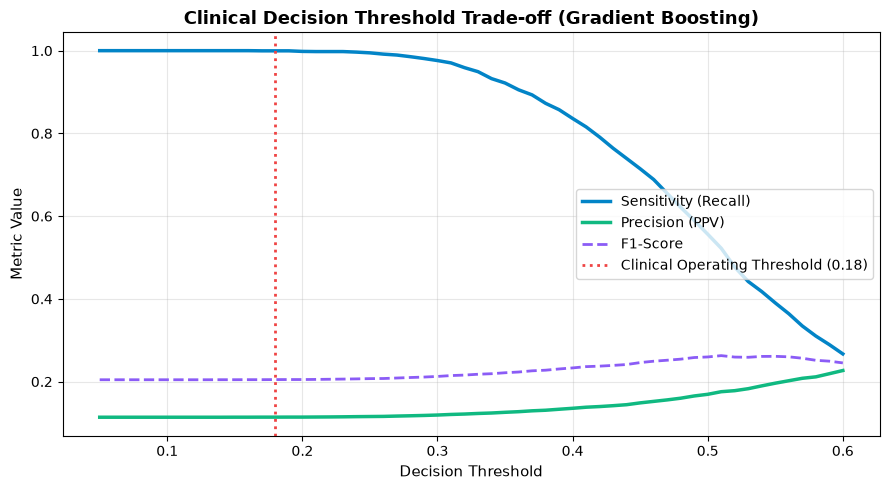

In [3]:

# Plotting Sensitivity vs Precision Trade-off Curve
gb_curve = pd.DataFrame(report['models_comparison']['Gradient Boosting (Balanced)']['threshold_curve'])

plt.figure(figsize=(9, 5))
plt.plot(gb_curve['threshold'], gb_curve['sensitivity_recall'], label='Sensitivity (Recall)', color='#0284c7', lw=2.5)
plt.plot(gb_curve['threshold'], gb_curve['precision_ppv'], label='Precision (PPV)', color='#10b981', lw=2.5)
plt.plot(gb_curve['threshold'], gb_curve['f1_score'], label='F1-Score', color='#8b5cf6', linestyle='--', lw=2)
plt.axvline(x=0.18, color='#ef4444', linestyle=':', label='Clinical Operating Threshold (0.18)', lw=2)
plt.title('Clinical Decision Threshold Trade-off (Gradient Boosting)', fontsize=13, fontweight='bold')
plt.xlabel('Decision Threshold', fontsize=11)
plt.ylabel('Metric Value', fontsize=11)
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
